In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import random

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [45]:
class SiameseMNIST(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset
        self.data = mnist_dataset.data
        self.labels = mnist_dataset.targets
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        img1, label1 = self.data[idx], self.labels[idx]

        should_match = random.randint(0,1)

        if should_match:
            mask = self.labels == label1
            idx2 = random.choice(mask.nonzero(as_tuple=True)[0])
            label = 1
        else:
            mask = self.labels != label1
            idx2 = random.choice(mask.nonzero(as_tuple=True)[0])
            label = 0

        img2 = self.data[idx2] 
        # Normalize
        img1 = img1.unsqueeze(0).float() / 255.0 
        img2 = img2.unsqueeze(0).float() / 255.0 
        return img1, img2, torch.tensor(label, dtype=torch.float32)

In [78]:
data = SiameseMNIST(train_dataset)
train_loader = DataLoader(data, batch_size=64, shuffle=True)

for datapoint in train_loader:
    print(type(datapoint[0]))
    print((datapoint[0].shape))
    print((datapoint[0]))
    break

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 

In [33]:
class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 5 * 5, 128)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = F.normalize(x, p=2, dim=1) 
        return x

In [22]:
class SiameseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = EmbeddingNet()

    def forward(self, x1, x2):
        out1 = self.network(x1)
        out2 = self.network(x2)
        return out1, out2

In [35]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):

        cos_sim = F.cosine_similarity(out1, out2)

        loss = torch.mean(
            label * (1 - cos_sim) +
            (1 - label) * torch.clamp(cos_sim - self.margin, min=0)
        )

        return loss

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SiameseNet().to(device)
criterion = ContrastiveLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch}")

    for img1, img2, label in loop:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        optimizer.zero_grad()

        out1, out2 = model(img1, img2)
        loss = criterion(out1, out2, label)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch} Avg Loss: {total_loss / len(train_loader):.4f}")

Epoch 0: 100%|██████████| 938/938 [02:40<00:00,  5.83it/s, loss=0.0448]


Epoch 0 Avg Loss: 0.0586


Epoch 1: 100%|██████████| 938/938 [02:27<00:00,  6.34it/s, loss=0.0397]


Epoch 1 Avg Loss: 0.0330


Epoch 2: 100%|██████████| 938/938 [02:30<00:00,  6.24it/s, loss=0.0173]


Epoch 2 Avg Loss: 0.0274


Epoch 3: 100%|██████████| 938/938 [02:19<00:00,  6.73it/s, loss=0.0235] 


Epoch 3 Avg Loss: 0.0252


Epoch 4: 100%|██████████| 938/938 [02:16<00:00,  6.87it/s, loss=0.0148] 

Epoch 4 Avg Loss: 0.0230


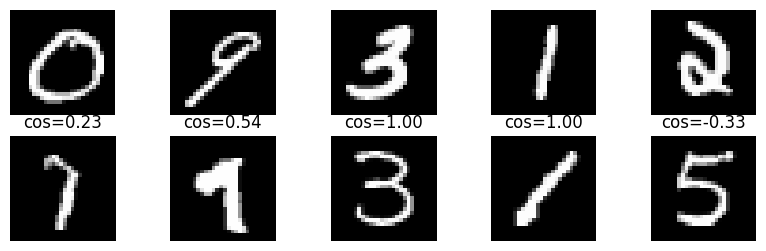

In [44]:
model.eval()

# get a batch
img1, img2, label = next(iter(train_loader))

img1 = img1.to(device)
img2 = img2.to(device)

with torch.no_grad():
    out1, out2 = model(img1, img2)

    # cosine similarity (-1 to 1)
    cos_sim = F.cosine_similarity(out1, out2)

# move to CPU for plotting
img1 = img1.cpu()
img2 = img2.cpu()

n = 5
plt.figure(figsize=(10, 3))

for i in range(n):
    # first image
    plt.subplot(2, n, i+1)
    plt.imshow(img1[i].squeeze(), cmap='gray')
    plt.axis('off')

    # second image
    plt.subplot(2, n, i+1+n)
    plt.imshow(img2[i].squeeze(), cmap='gray')
    plt.title(f"cos={cos_sim[i]:.2f}")
    plt.axis('off')

plt.show()